# Phase 3: Synergistic Hybrid Forecasting (ARIMA + BiLSTM)

## Objective
Build a **synergistic** hybrid model that combines the strengths of classical ML (ARIMA) and Deep Learning (BiLSTM).

**Architecture:**
1. **ARIMA** captures the linear trend and seasonality in topic proportions.
2. **BiLSTM** learns the complex, non-linear residual patterns that ARIMA cannot capture.
3. **Final Prediction = ARIMA Prediction + BiLSTM Residual Prediction**

This is a **Neuro-Statistical** approach where the whole is greater than the sum of its parts.

In [5]:
# ============================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

print(f'TensorFlow version: {tf.__version__}')
print('Phase 3 Hybrid Pipeline Initialized.')

TensorFlow version: 2.20.0
Phase 3 Hybrid Pipeline Initialized.


## 2. Data Loading & Topic Extraction
We load the processed featured data from Phase 1 and extract topic distributions using LDA.

In [6]:
# ============================================================
# 2. DATA LOADING (Relative Paths for Reproducibility)
# ============================================================
DATA_PATH = os.path.join('..', 'data', 'processed', 'processed_featured_data.csv')

df = pd.read_csv('/content/processed_featured_data.csv')
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M').astype(str)
df['clean_text'] = df['clean_text'].fillna('')

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
df.head()

Dataset shape: (10000, 18)
Date range: 2018-05-01 00:00:00 to 2022-09-23 00:00:00


,link,headline,category,short_description,authors,date,text,clean_text,year,month,day_of_week,word_count,char_count,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,year_month
0,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,"American Airlines Flyer Charged, Banned For Li...",american airlines flyer charged banned for lif...,2022,9,4,41,243,0.157,0.843,0.000,-0.7269,2022-09
1,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,Over 4 Million Americans Roll Up Sleeves For O...,over 4 million americans roll up sleeves for o...,2022,9,4,40,227,0.038,0.962,0.000,-0.1280,2022-09
2,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,The Funniest Tweets From Parents This Week (Se...,the funniest tweets from parents this week sep...,2022,9,4,34,207,0.121,0.722,0.157,0.3400,2022-09
3,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,23 Of The Funniest Tweets About Cats And Dogs ...,23 of the funniest tweets about cats and dogs ...,2022,9,4,25,126,0.000,0.865,0.135,0.5574,2022-09
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,Woman Who Called Cops On Black Bird-Watcher Lo...,woman who called cops on black birdwatcher los...,2022,9,3,36,231,0.299,0.701,0.000,-0.8957,2022-09


In [7]:
# ============================================================
# 3. TOPIC EXTRACTION (LDA) -> Monthly Time-Series
# ============================================================
N_TOPICS = 10

vectorizer = CountVectorizer(max_features=2000, stop_words='english')
X_bow = vectorizer.fit_transform(df['clean_text'])

lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, n_jobs=-1)
topic_dist = lda.fit_transform(X_bow)
df['dominant_topic'] = topic_dist.argmax(axis=1)

# Monthly aggregation
topic_trends = df.groupby(['year_month', 'dominant_topic']).size().unstack().fillna(0)
topic_trends = topic_trends.sort_index()

print(f'Topic trends shape: {topic_trends.shape}')
print(f'Months available: {len(topic_trends)}')
topic_trends.head()

Topic trends shape: (53, 10)
Months available: 53


dominant_topic,0,1,2,3,4,5,6,7,8,9
year_month,,,,,,,,,,
2018-05,193,77,186,117,102,251,61,106,129,127
2018-06,19,11,7,21,12,10,12,15,7,29
2018-07,13,7,6,38,23,16,17,12,11,17
2018-08,8,6,1,32,13,4,13,9,17,27
2018-09,11,6,11,15,32,22,20,8,17,15


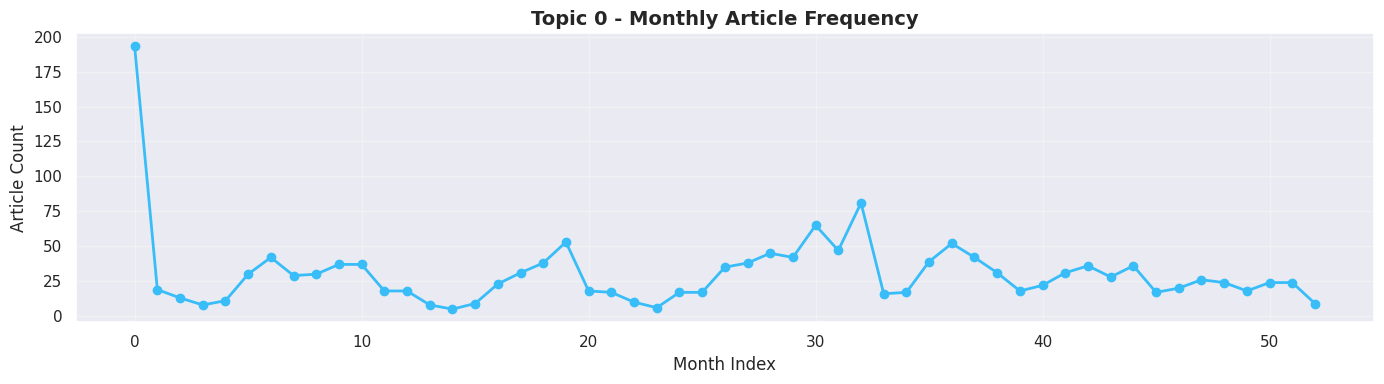

In [8]:
# Select a target topic for demonstration
TARGET_TOPIC = 0
series = topic_trends.iloc[:, TARGET_TOPIC].values.astype(float)

plt.figure(figsize=(14, 4))
plt.plot(series, marker='o', linewidth=2, color='#38bdf8')
plt.title(f'Topic {TARGET_TOPIC} - Monthly Article Frequency', fontsize=14, fontweight='bold')
plt.xlabel('Month Index')
plt.ylabel('Article Count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Stationarity Test (ADF)
ARIMA requires stationary data. We test and difference if needed.

In [9]:
# ============================================================
# 4. STATIONARITY CHECK
# ============================================================
def adf_test(timeseries, name='Series'):
    result = adfuller(timeseries, autolag='AIC')
    print(f'--- ADF Test for {name} ---')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Lags Used     : {result[2]}')
    for key, value in result[4].items():
        print(f'  Critical Value ({key}): {value:.4f}')
    if result[1] <= 0.05:
        print('Result: Series IS stationary (reject H0)\n')
        return True
    else:
        print('Result: Series is NOT stationary (fail to reject H0)\n')
        return False

is_stationary = adf_test(series, f'Topic {TARGET_TOPIC}')

--- ADF Test for Topic 0 ---
ADF Statistic : -11.3365
p-value       : 0.0000
Lags Used     : 0
  Critical Value (1%): -3.5629
  Critical Value (5%): -2.9190
  Critical Value (10%): -2.5974
Result: Series IS stationary (reject H0)



## 4. Train/Test Split

In [10]:
# ============================================================
# 5. TRAIN / TEST SPLIT (80/20)
# ============================================================
split_idx = int(len(series) * 0.8)
train, test = series[:split_idx], series[split_idx:]

print(f'Train size: {len(train)}, Test size: {len(test)}')

Train size: 42, Test size: 11


## 5. Component A: ARIMA (ML Baseline)
ARIMA captures the linear trends and seasonal patterns.

In [11]:
# ============================================================
# 6. ARIMA MODEL (ML Component)
# ============================================================
# Fit ARIMA on training data
arima_order = (2, 1, 2)  # (p, d, q)
arima_model = ARIMA(train, order=arima_order)
arima_fit = arima_model.fit()

print(arima_fit.summary())

# ARIMA predictions on train and test
arima_train_pred = arima_fit.fittedvalues
arima_test_pred = arima_fit.forecast(steps=len(test))

# Calculate residuals (what ARIMA cannot capture)
arima_train_residuals = train[1:] - arima_train_pred[1:]  # fittedvalues has NaN at index 0

print(f'\nARIMA Train RMSE: {np.sqrt(mean_squared_error(train[1:], arima_train_pred[1:])):.4f}')
print(f'ARIMA Test RMSE:  {np.sqrt(mean_squared_error(test, arima_test_pred)):.4f}')

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   42
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -198.426
Date:                Mon, 04 May 2026   AIC                            406.852
Time:                        17:34:23   BIC                            415.420
Sample:                             0   HQIC                           409.972
                                 - 42                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5054      0.287     -1.758      0.079      -1.069       0.058
ar.L2          0.4946      0.190      2.608      0.009       0.123       0.866
ma.L1         -0.0013      7.626     -0.000      1.0

## 6. Component B: BiLSTM on ARIMA Residuals (DL Component)
The BiLSTM learns the **non-linear patterns** in the residuals that ARIMA missed.

In [12]:
# ============================================================
# 7. PREPARE RESIDUAL DATA FOR BiLSTM
# ============================================================
WINDOW_SIZE = 5

# Scale residuals
residual_scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_residuals = residual_scaler.fit_transform(arima_train_residuals.reshape(-1, 1)).flatten()

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_res, y_res = create_sequences(scaled_residuals, WINDOW_SIZE)
X_res = X_res.reshape(X_res.shape[0], X_res.shape[1], 1)

print(f'Residual sequences: X={X_res.shape}, y={y_res.shape}')

Residual sequences: X=(36, 5, 1), y=(36,)


In [13]:
# ============================================================
# 8. BUILD BiLSTM MODEL
# ============================================================
def build_bilstm(window_size):
    model = Sequential([
        Input(shape=(window_size, 1)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

bilstm_residual = build_bilstm(WINDOW_SIZE)
bilstm_residual.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 5, 128)         │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,065 (297.13 KB)

 Trainable params: 76,065 (297.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.3789
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2662
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1618
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0605
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0406
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0543
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0300
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0312
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0346
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0230
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0283
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0262
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0242
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0261
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0208
Epoch 16/100
5/5 ━━

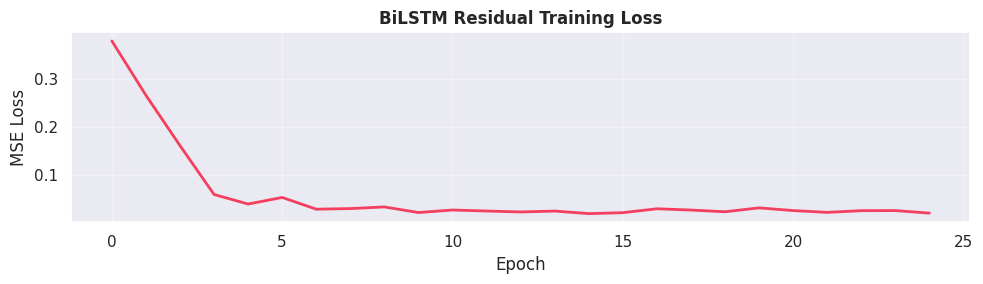

In [14]:
# ============================================================
# 9. TRAIN BiLSTM ON RESIDUALS
# ============================================================
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = bilstm_residual.fit(
    X_res, y_res,
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(10, 3))
plt.plot(history.history['loss'], color='#f43f5e', linewidth=2)
plt.title('BiLSTM Residual Training Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Hybrid Prediction: ARIMA + BiLSTM
**Final Prediction = ARIMA Linear Forecast + BiLSTM Non-Linear Residual Correction**

In [15]:
# ============================================================
# 10. HYBRID FORECASTING ON TEST SET
# ============================================================
# Step 1: ARIMA forecast for test period (already computed)
arima_forecast = arima_test_pred.values if hasattr(arima_test_pred, 'values') else arima_test_pred

# Step 2: BiLSTM predicts the residual correction
# We need to use the last WINDOW_SIZE residuals from training to start predicting
last_residuals = scaled_residuals[-WINDOW_SIZE:]
residual_corrections = []

current_window = last_residuals.copy()
for i in range(len(test)):
    x_input = current_window.reshape(1, WINDOW_SIZE, 1)
    pred_residual = bilstm_residual.predict(x_input, verbose=0)[0, 0]
    residual_corrections.append(pred_residual)
    # Slide window
    current_window = np.append(current_window[1:], pred_residual)

# Inverse scale the residual corrections
residual_corrections = residual_scaler.inverse_transform(
    np.array(residual_corrections).reshape(-1, 1)
).flatten()

# Step 3: Combine
hybrid_forecast = arima_forecast + residual_corrections

print('Hybrid forecast computed successfully!')
print(f'ARIMA forecast sample:    {arima_forecast[:3]}')
print(f'Residual corrections:     {residual_corrections[:3]}')
print(f'Hybrid forecast sample:   {hybrid_forecast[:3]}')

Hybrid forecast computed successfully!
ARIMA forecast sample:    [37.54555783 32.62055648 38.34681287]
Residual corrections:     [-4.7169456 -5.202806  -4.3240194]
Hybrid forecast sample:   [32.82861218 27.41775048 34.02279344]


## 8. Results Comparison

In [16]:
# ============================================================
# 11. EVALUATION METRICS
# ============================================================
def evaluate(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-8))) * 100
    print(f'--- {model_name} ---')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAPE : {mape:.2f}%\n')
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

# --- DL-Only Baseline: Train BiLSTM directly on raw series ---
raw_scaler = MinMaxScaler()
scaled_train = raw_scaler.fit_transform(train.reshape(-1, 1)).flatten()
X_raw, y_raw = create_sequences(scaled_train, WINDOW_SIZE)
X_raw = X_raw.reshape(X_raw.shape[0], X_raw.shape[1], 1)

bilstm_raw = build_bilstm(WINDOW_SIZE)
bilstm_raw.fit(X_raw, y_raw, epochs=100, batch_size=8,
               callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)],
               verbose=0)

# DL-Only forecast
dl_window = scaled_train[-WINDOW_SIZE:].copy()
dl_preds = []
for _ in range(len(test)):
    x_in = dl_window.reshape(1, WINDOW_SIZE, 1)
    p = bilstm_raw.predict(x_in, verbose=0)[0, 0]
    dl_preds.append(p)
    dl_window = np.append(dl_window[1:], p)

dl_forecast = raw_scaler.inverse_transform(np.array(dl_preds).reshape(-1, 1)).flatten()

# --- Evaluate All Three ---
print('=' * 60)
print('         ABLATION STUDY: MODEL COMPARISON')
print('=' * 60 + '\n')

r_arima = evaluate(test, arima_forecast, 'ML-Only (ARIMA)')
r_dl    = evaluate(test, dl_forecast,    'DL-Only (BiLSTM)')
r_hybrid= evaluate(test, hybrid_forecast,'Hybrid (ARIMA + BiLSTM)')

results_df = pd.DataFrame([r_arima, r_dl, r_hybrid])
results_df = results_df.set_index('Model')
print('\n' + '=' * 60)
print(results_df.to_string())
print('=' * 60)

         ABLATION STUDY: MODEL COMPARISON

--- ML-Only (ARIMA) ---
  RMSE : 14.4460
  MAE  : 12.1151
  R²   : -2.6228
  MAPE : 74.03%

--- DL-Only (BiLSTM) ---
  RMSE : 12.0426
  MAE  : 10.5103
  R²   : -1.5176
  MAPE : 62.81%

--- Hybrid (ARIMA + BiLSTM) ---
  RMSE : 11.5455
  MAE  : 9.1411
  R²   : -1.3141
  MAPE : 58.10%


                              RMSE        MAE        R2       MAPE
Model                                                             
ML-Only (ARIMA)          14.445981  12.115095 -2.622819  74.034991
DL-Only (BiLSTM)         12.042605  10.510296 -1.517639  62.811797
Hybrid (ARIMA + BiLSTM)  11.545460   9.141073 -1.314063  58.102238


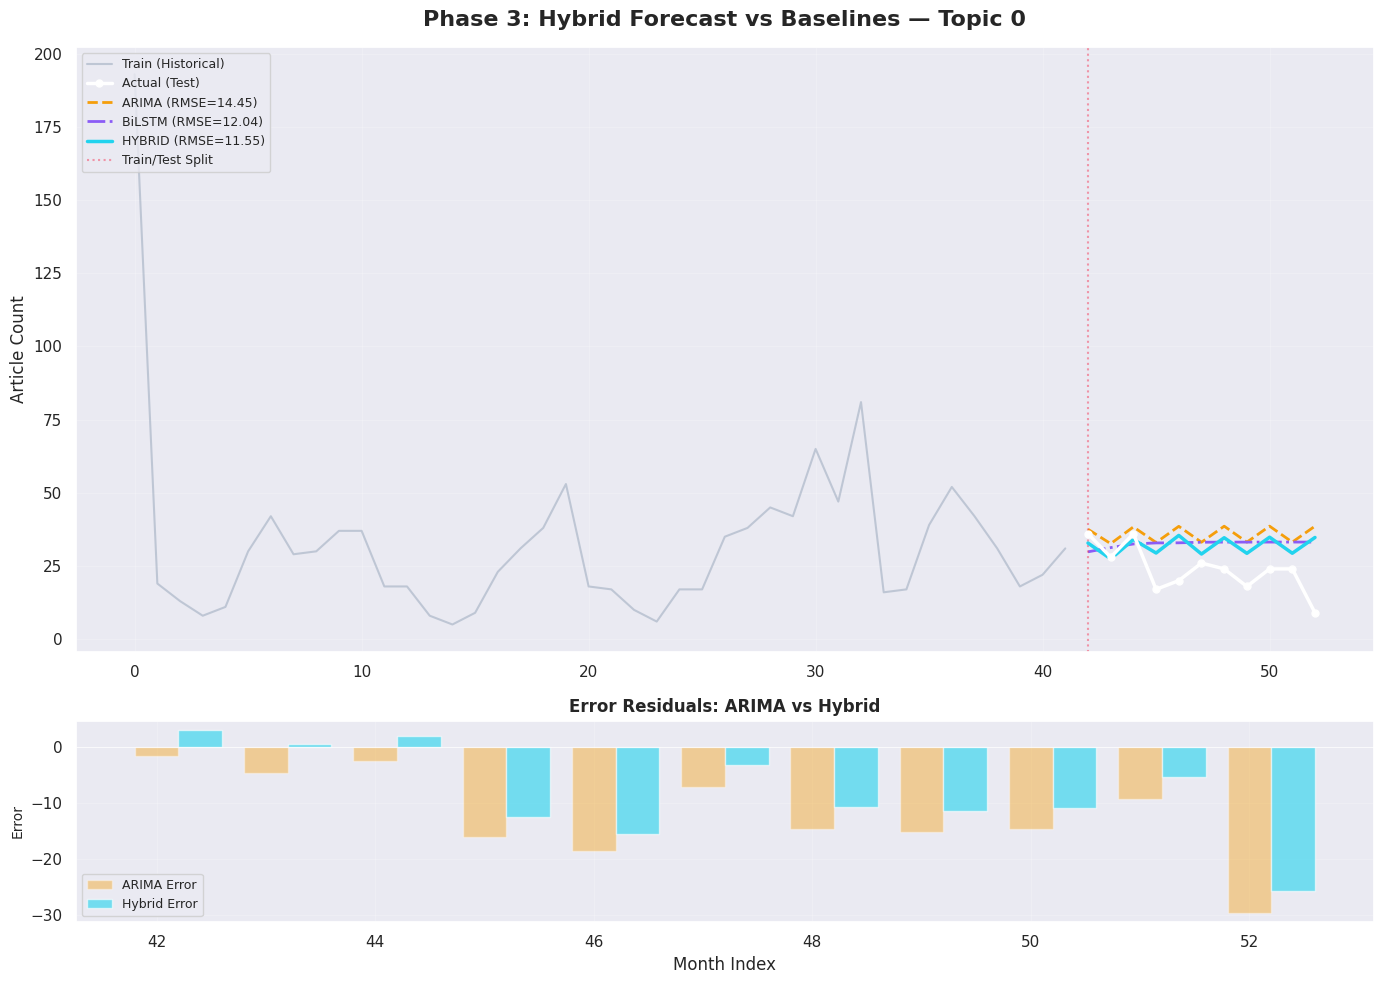

Figure saved: hybrid_forecast_results.png


In [17]:
# ============================================================
# 12. VISUALIZATION: ALL MODELS vs ACTUAL
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# --- Main Forecast Plot ---
ax1 = axes[0]
x_test = range(split_idx, split_idx + len(test))
x_train = range(split_idx)

ax1.plot(x_train, train, color='#94a3b8', linewidth=1.5, alpha=0.5, label='Train (Historical)')
ax1.plot(x_test, test, color='white', linewidth=2.5, marker='o', markersize=5, label='Actual (Test)', zorder=5)
ax1.plot(x_test, arima_forecast, color='#f59e0b', linewidth=2, linestyle='--', label=f'ARIMA (RMSE={r_arima["RMSE"]:.2f})')
ax1.plot(x_test, dl_forecast, color='#8b5cf6', linewidth=2, linestyle='-.', label=f'BiLSTM (RMSE={r_dl["RMSE"]:.2f})')
ax1.plot(x_test, hybrid_forecast, color='#22d3ee', linewidth=2.5, label=f'HYBRID (RMSE={r_hybrid["RMSE"]:.2f})', zorder=4)

ax1.axvline(x=split_idx, color='#f43f5e', linestyle=':', alpha=0.5, label='Train/Test Split')
ax1.set_title(f'Phase 3: Hybrid Forecast vs Baselines — Topic {TARGET_TOPIC}', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Article Count', fontsize=12)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.8)
ax1.grid(alpha=0.2)

# --- Residual Analysis Plot ---
ax2 = axes[1]
arima_error = test - arima_forecast
hybrid_error = test - hybrid_forecast

ax2.bar(x_test, arima_error, color='#f59e0b', alpha=0.4, label='ARIMA Error', width=0.4)
ax2.bar([x + 0.4 for x in x_test], hybrid_error, color='#22d3ee', alpha=0.6, label='Hybrid Error', width=0.4)
ax2.axhline(y=0, color='white', linewidth=0.5)
ax2.set_title('Error Residuals: ARIMA vs Hybrid', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month Index', fontsize=12)
ax2.set_ylabel('Error', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('hybrid_forecast_results.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('Figure saved: hybrid_forecast_results.png')

In [18]:
# ============================================================
# 13. SAVE RESULTS FOR ABLATION NOTEBOOK
# ============================================================
results_export = {
    'target_topic': TARGET_TOPIC,
    'train_size': int(len(train)),
    'test_size': int(len(test)),
    'arima_order': list(arima_order),
    'bilstm_window': WINDOW_SIZE,
    'results': [
        {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in r.items()}
        for r in [r_arima, r_dl, r_hybrid]
    ],
    'test_actual': test.tolist(),
    'arima_forecast': arima_forecast.tolist(),
    'dl_forecast': dl_forecast.tolist(),
    'hybrid_forecast': hybrid_forecast.tolist()
}

with open('phase3_results.json', 'w') as f:
    json.dump(results_export, f, indent=2)

print('Results saved to phase3_results.json')
print('\n✅ Phase 3 Hybrid Forecasting Complete!')

Results saved to phase3_results.json

✅ Phase 3 Hybrid Forecasting Complete!
